In [1]:
import sys
sys.path.append('../')

from pqcqec.simulate.jax_statevector import build_jax_circuit, jax_run_many_states
from pqcqec.simulate.simulate import get_input_data
from pqcqec.noise.builder import add_noise_to_base_ops
from pqcqec.training.jax_loss_functions import jax_pure_state_fidelity, jax_pure_state_fidelity_batched  


# Quantum Circuit Fidelity Analysis - Optimized Version

This notebook simulates all possible circuit permutations and measures their fidelity under noise.

## Performance Optimizations Applied:
1. ✅ **JAX JIT pre-compilation** - Warm-up run to compile functions before timing
2. ✅ **Batched fidelity calculations** - Using `vmap` for parallel state processing  
3. ✅ **Pre-allocated numpy arrays** - Efficient memory usage with float32
4. ✅ **Reduced print statements** - Only progress updates every 5000 circuits
5. ✅ **Timing and throughput tracking** - Real-time ETA and circuits/sec
6. ✅ **Optimized data structures** - Direct numpy arrays instead of lists

## Quick Start
Run cells in order. With 59,049 circuits and optimizations:
- **Expected time**: 5-30 minutes (depends on hardware)
- **Memory**: ~500MB
- **Progress tracking**: Live ETA updates every 5000 circuits

In [2]:
import numpy as np
from itertools import permutations, product
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
import jax
import jax.numpy as jnp

# Check if GPU is available
print(f"JAX devices: {jax.devices()}")
print(f"Default backend: {jax.default_backend()}")

JAX devices: [CpuDevice(id=0)]
Default backend: cpu


In [4]:
GATES = ['x', 'z', 'h',]
NUM_GATES = 10
NUM_QUBITS = 1
NUM_VALS = 1000

OUT_LOG_FILE = "gate_fidelity_results.log"

X_NOISE = np.ones((NUM_GATES)) * 0.1
Z_NOISE = np.ones((NUM_GATES)) * 0.1

print('X Noise:', X_NOISE)
print('Z Noise:', Z_NOISE)


X Noise: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Z Noise: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


In [5]:
INPUT_STATES = get_input_data(NUM_QUBITS, NUM_VALS)

print("Input states shape:", INPUT_STATES.shape)
print("Input States sample:", INPUT_STATES[0])

Input states shape: (1000, 2)
Input States sample: [ 0.2905725-0.7068729j  -0.2623037-0.58914775j]


In [6]:
# Check if the state is normalized
sample_state = INPUT_STATES[0]
norm = np.sum(np.abs(sample_state)**2)
print(f"Norm of sample state: {norm}")
print(f"Is normalized: {np.isclose(norm, 1.0)}")

# Check a few more states
print("\nChecking first 5 states:")
for i in range(5):
    norm = np.sum(np.abs(INPUT_STATES[i])**2)
    print(f"State {i}: norm = {norm:.10f}, normalized = {np.isclose(norm, 1.0)}")

Norm of sample state: 0.9999998807907104
Is normalized: True

Checking first 5 states:
State 0: norm = 0.9999998808, normalized = True
State 1: norm = 0.9999999404, normalized = True
State 2: norm = 1.0000001192, normalized = True
State 3: norm = 1.0000000000, normalized = True
State 4: norm = 1.0000000000, normalized = True


In [7]:
gate_sequences = [(g, [0], 0.0) for g in GATES]
print(gate_sequences)

[('x', [0], 0.0), ('z', [0], 0.0), ('h', [0], 0.0)]


In [8]:
all_possible_circuits = list(product(gate_sequences, repeat=NUM_GATES))
print(f"Total circuits to simulate: {len(all_possible_circuits)}")

Total circuits to simulate: 59049


## Pre-compilation: Warm up JAX JIT
Run a dummy circuit first to trigger JAX compilation, so the timed loop doesn't include compilation overhead.

In [9]:
# Warm up JAX JIT compilation with a dummy circuit
print("Warming up JAX JIT compilation...")
dummy_circ = all_possible_circuits[0]

dummy_jax_circuit = build_jax_circuit(circuit_ops=dummy_circ)
_ = jax_run_many_states(NUM_QUBITS, *dummy_jax_circuit, INPUT_STATES)

dummy_noisy_ops = add_noise_to_base_ops(base_ops=dummy_circ, x_noise=X_NOISE, z_noise=Z_NOISE)
dummy_noisy_circuit = build_jax_circuit(circuit_ops=dummy_noisy_ops)
_ = jax_run_many_states(NUM_QUBITS, *dummy_noisy_circuit, INPUT_STATES)

# Warm up fidelity calculation
dummy_fids = jax_pure_state_fidelity_batched(INPUT_STATES, INPUT_STATES)

print("✓ JIT compilation complete. Starting optimized simulation...")

Warming up JAX JIT compilation...


✓ JIT compilation complete. Starting optimized simulation...


## Optional: Further Speed Optimizations

You can try these additional optimizations:
1. **Reduce NUM_VALS** for testing (e.g., 100 instead of 1000)
2. **Use fewer gates** for prototyping (e.g., NUM_GATES = 5 → 243 circuits instead of 59,049)
3. **Enable JAX GPU** if available (requires CUDA setup)
4. **Batch multiple circuits** together (more complex implementation)

In [10]:
import time

# Pre-allocate arrays for better memory efficiency
num_circuits = len(all_possible_circuits)
circuit_names = []
total_fidelity = np.zeros(num_circuits, dtype=np.float32)

start_time = time.time()

# Use tqdm for progress tracking
for i, circ in enumerate(tqdm(all_possible_circuits, desc="Simulating circuits")):

    # Build ideal circuit
    jax_circuit = build_jax_circuit(circuit_ops=circ)
    ideal_measured_states = jax_run_many_states(NUM_QUBITS, *jax_circuit, INPUT_STATES)

    # Build noisy circuit
    noisy_base_ops = add_noise_to_base_ops(base_ops=circ, x_noise=X_NOISE, z_noise=Z_NOISE)
    noisy_jax_circuit = build_jax_circuit(circuit_ops=noisy_base_ops)
    noisy_measured_states = jax_run_many_states(NUM_QUBITS, *noisy_jax_circuit, INPUT_STATES)

    # Calculate fidelities and store mean
    fidelities = jax_pure_state_fidelity_batched(ideal_measured_states, noisy_measured_states)
    total_fidelity[i] = float(np.mean(fidelities))
    
    # Store circuit name
    circ_gates_str = '-'.join([g[0] for g in circ])
    circuit_names.append(circ_gates_str)
    
    # Print progress at intervals
    if i % 5000 == 0 and i > 0:
        elapsed = time.time() - start_time
        rate = i / elapsed
        eta = (num_circuits - i) / rate
        print(f"  Progress: {i}/{num_circuits} | Rate: {rate:.1f} circuits/sec | ETA: {eta:.1f}s | Current fidelity: {total_fidelity[i]:.4f}")

elapsed_time = time.time() - start_time
print(f"\n✓ Simulation complete in {elapsed_time:.2f} seconds ({num_circuits/elapsed_time:.1f} circuits/sec)")

# Create combined list for file output
circuit_fids = list(zip(circuit_names, total_fidelity))

Simulating circuits:   9%|▊         | 5076/59049 [00:12<02:14, 402.62it/s]

  Progress: 5000/59049 | Rate: 395.8 circuits/sec | ETA: 136.6s | Current fidelity: 0.9728


Simulating circuits:  17%|█▋        | 10075/59049 [00:25<02:02, 400.33it/s]

  Progress: 10000/59049 | Rate: 394.3 circuits/sec | ETA: 124.4s | Current fidelity: 0.9414


Simulating circuits:  25%|██▌       | 15046/59049 [00:37<01:48, 406.72it/s]

...

  Progress: 50000/59049 | Rate: 396.6 circuits/sec | ETA: 22.8s | Current fidelity: 0.8925


Simulating circuits:  93%|█████████▎| 55071/59049 [02:18<00:09, 408.03it/s]

  Progress: 55000/59049 | Rate: 396.6 circuits/sec | ETA: 10.2s | Current fidelity: 0.9872


Simulating circuits: 100%|██████████| 59049/59049 [02:28<00:00, 396.49it/s]


✓ Simulation complete in 148.93 seconds (396.5 circuits/sec)


In [11]:
print("Net circuit fidelity (mean): ", np.mean(total_fidelity))

Net circuit fidelity (mean):  0.94178957


In [12]:
# Analyze results (total_fidelity is already a numpy array)
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Total circuits simulated: {len(all_possible_circuits)}")
print(f"Mean circuit fidelity: {np.mean(total_fidelity):.6f}")
print(f"Median circuit fidelity: {np.median(total_fidelity):.6f}")
print(f"Std deviation: {np.std(total_fidelity):.6f}")
print(f"Min fidelity: {np.min(total_fidelity):.6f}")
print(f"Max fidelity: {np.max(total_fidelity):.6f}")
print("=" * 60)

# Find best and worst circuits
best_idx = np.argmax(total_fidelity)
worst_idx = np.argmin(total_fidelity)

print(f"\nBest circuit: {circuit_names[best_idx]} | Fidelity: {total_fidelity[best_idx]:.6f}")
print(f"Worst circuit: {circuit_names[worst_idx]} | Fidelity: {total_fidelity[worst_idx]:.6f}")

SUMMARY STATISTICS
Total circuits simulated: 59049
Mean circuit fidelity: 0.941790
Median circuit fidelity: 0.948560
Std deviation: 0.046104
Min fidelity: 0.717086
Max fidelity: 0.999999

Best circuit: z-h-x-z-z-x-z-x-x-x | Fidelity: 0.999999
Worst circuit: z-h-h-h-h-h-h-h-h-h | Fidelity: 0.717086


## Advanced Noise Impact Analysis

These additional metrics help characterize how noise affects your quantum circuits:

### Key Metrics:

1. **Infidelity (1 - F)**: Direct measure of error rate
2. **Error per Gate**: Average error accumulated per gate operation
3. **Fidelity Decay Rate (λ)**: How fast fidelity degrades (exponential model)
4. **Signal-to-Noise Ratio (SNR)**: Quality metric in dB
5. **Percentiles**: Distribution of fidelity across all circuits
6. **Robustness Thresholds**: Percentage of circuits meeting quality targets
7. **Coefficient of Variation**: Uniformity of noise impact
8. **Skewness/Kurtosis**: Shape of distribution (symmetry, tail behavior)
9. **Shannon Entropy**: Unpredictability of noise impact
10. **Gate Position Sensitivity**: Which gates in which positions are most vulnerable
11. **Gate Composition**: Which gate types perform best under noise

In [13]:
# 1. Infidelity (Error Rate)
infidelity = 1 - total_fidelity
mean_infidelity = np.mean(infidelity)

# 2. Error per gate (assuming uniform distribution)
error_per_gate = 1 - (total_fidelity ** (1/NUM_GATES))

# 3. Fidelity decay rate (exponential model: F = F0 * e^(-λn))
# λ = -ln(F) / n where n = NUM_GATES
decay_rate = -np.log(total_fidelity) / NUM_GATES

# 4. Signal-to-Noise Ratio (SNR) in dB
# SNR = 10 * log10(signal/noise) where signal=fidelity, noise=infidelity
snr_db = 10 * np.log10(total_fidelity / (infidelity + 1e-10))

# 5. Percentile analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
fidelity_percentiles = np.percentile(total_fidelity, percentiles)

print("=" * 70)
print("NOISE IMPACT METRICS")
print("=" * 70)
print(f"\n1. INFIDELITY (1 - F):")
print(f"   Mean infidelity: {mean_infidelity:.6f}")
print(f"   Max infidelity:  {np.max(infidelity):.6f}")
print(f"   Min infidelity:  {np.min(infidelity):.6f}")

print(f"\n2. ERROR PER GATE:")
print(f"   Mean error/gate: {np.mean(error_per_gate):.6f}")
print(f"   Std error/gate:  {np.std(error_per_gate):.6f}")

print(f"\n3. FIDELITY DECAY RATE (λ):")
print(f"   Mean decay rate: {np.mean(decay_rate):.6f}")
print(f"   For exponential model: F(n) = e^(-λn)")

print(f"\n4. SIGNAL-TO-NOISE RATIO:")
print(f"   Mean SNR: {np.mean(snr_db):.2f} dB")
print(f"   Median SNR: {np.median(snr_db):.2f} dB")

print(f"\n5. FIDELITY PERCENTILES:")
for p, val in zip(percentiles, fidelity_percentiles):
    print(f"   {p:2d}th percentile: {val:.6f}")

# 6. Robustness metrics
threshold_90 = np.sum(total_fidelity > 0.9) / len(total_fidelity) * 100
threshold_80 = np.sum(total_fidelity > 0.8) / len(total_fidelity) * 100
threshold_70 = np.sum(total_fidelity > 0.7) / len(total_fidelity) * 100

print(f"\n6. CIRCUIT ROBUSTNESS (Fidelity Thresholds):")
print(f"   > 90%: {threshold_90:.2f}% of circuits")
print(f"   > 80%: {threshold_80:.2f}% of circuits")
print(f"   > 70%: {threshold_70:.2f}% of circuits")

# 7. Coefficient of Variation (relative variability)
cv = np.std(total_fidelity) / np.mean(total_fidelity)
print(f"\n7. COEFFICIENT OF VARIATION:")
print(f"   CV = {cv:.4f} (lower = more uniform noise impact)")

print("=" * 70)

NOISE IMPACT METRICS

1. INFIDELITY (1 - F):
   Mean infidelity: 0.058210
   Max infidelity:  0.282914
   Min infidelity:  0.000001

2. ERROR PER GATE:
   Mean error/gate: 0.006090
   Std error/gate:  0.004978

3. FIDELITY DECAY RATE (λ):
   Mean decay rate: 0.006121
   For exponential model: F(n) = e^(-λn)

4. SIGNAL-TO-NOISE RATIO:
   Mean SNR: 14.19 dB
   Median SNR: 12.66 dB

5. FIDELITY PERCENTILES:
   10th percentile: 0.876373
   25th percentile: 0.917286
   50th percentile: 0.948560
   75th percentile: 0.974365
   90th percentile: 0.992842
   95th percentile: 0.993474
   99th percentile: 0.999926

6. CIRCUIT ROBUSTNESS (Fidelity Thresholds):
   > 90%: 78.55% of circuits
   > 80%: 99.52% of circuits
   > 70%: 100.00% of circuits

7. COEFFICIENT OF VARIATION:
   CV = 0.0490 (lower = more uniform noise impact)


In [14]:
# Gate composition analysis - which gate sequences perform best/worst
from collections import Counter

# Count gate occurrences in best/worst circuits
n_top = 100
n_worst = 100

top_indices = np.argsort(total_fidelity)[-n_top:]
worst_indices = np.argsort(total_fidelity)[:n_worst]

# Analyze gate frequency in top/worst circuits
def count_gates_in_circuits(circuit_names_subset):
    gate_counts = Counter()
    for name in circuit_names_subset:
        gates = name.split('-')
        gate_counts.update(gates)
    return gate_counts

top_gate_counts = count_gates_in_circuits([circuit_names[i] for i in top_indices])
worst_gate_counts = count_gates_in_circuits([circuit_names[i] for i in worst_indices])

total_gates_top = sum(top_gate_counts.values())
total_gates_worst = sum(worst_gate_counts.values())

print("=" * 70)
print("GATE COMPOSITION ANALYSIS")
print("=" * 70)
print(f"\nTop {n_top} circuits - Gate frequency:")
for gate in GATES:
    count = top_gate_counts[gate]
    pct = 100 * count / total_gates_top
    print(f"   {gate.upper()}: {count:4d} occurrences ({pct:5.2f}%)")

print(f"\nWorst {n_worst} circuits - Gate frequency:")
for gate in GATES:
    count = worst_gate_counts[gate]
    pct = 100 * count / total_gates_worst
    print(f"   {gate.upper()}: {count:4d} occurrences ({pct:5.2f}%)")

# Calculate relative preference (which gates appear more in top vs worst)
print(f"\nRelative gate preference (Top vs Worst):")
for gate in GATES:
    top_pct = 100 * top_gate_counts[gate] / total_gates_top
    worst_pct = 100 * worst_gate_counts[gate] / total_gates_worst
    diff = top_pct - worst_pct
    direction = "favored" if diff > 0 else "avoided"
    print(f"   {gate.upper()}: {diff:+6.2f}% ({direction} in high-fidelity circuits)")

print("=" * 70)

GATE COMPOSITION ANALYSIS

Top 100 circuits - Gate frequency:
   X:  399 occurrences (39.90%)
   Z:  392 occurrences (39.20%)
   H:  209 occurrences (20.90%)

Worst 100 circuits - Gate frequency:
   X:  159 occurrences (15.90%)
   Z:  164 occurrences (16.40%)
   H:  677 occurrences (67.70%)

Relative gate preference (Top vs Worst):
   X: +24.00% (favored in high-fidelity circuits)
   Z: +22.80% (favored in high-fidelity circuits)
   H: -46.80% (avoided in high-fidelity circuits)


In [15]:
# Statistical distribution tests
from scipy import stats

# 1. Test for normality
shapiro_stat, shapiro_p = stats.shapiro(total_fidelity[:5000])  # Sample for speed

# 2. Skewness and Kurtosis
skewness = stats.skew(total_fidelity)
kurtosis_val = stats.kurtosis(total_fidelity)

# 3. Interquartile Range (IQR) - measure of spread
q1 = np.percentile(total_fidelity, 25)
q3 = np.percentile(total_fidelity, 75)
iqr = q3 - q1

# 4. Range
fid_range = np.max(total_fidelity) - np.min(total_fidelity)

# 5. Variance decomposition
within_noise_var = np.var(total_fidelity)  # Total variance due to noise

print("=" * 70)
print("STATISTICAL DISTRIBUTION ANALYSIS")
print("=" * 70)
print(f"\n1. NORMALITY TEST (Shapiro-Wilk on sample):")
print(f"   Test statistic: {shapiro_stat:.6f}")
print(f"   P-value: {shapiro_p:.6e}")
print(f"   {'✓ Normally distributed' if shapiro_p > 0.05 else '✗ Not normally distributed'} (α=0.05)")

print(f"\n2. SHAPE STATISTICS:")
print(f"   Skewness: {skewness:.4f}")
if abs(skewness) < 0.5:
    skew_interp = "approximately symmetric"
elif skewness < 0:
    skew_interp = "left-skewed (tail extends left)"
else:
    skew_interp = "right-skewed (tail extends right)"
print(f"   → {skew_interp}")

print(f"\n   Kurtosis: {kurtosis_val:.4f}")
if abs(kurtosis_val) < 0.5:
    kurt_interp = "mesokurtic (normal-like tails)"
elif kurtosis_val > 0:
    kurt_interp = "leptokurtic (heavy tails, more outliers)"
else:
    kurt_interp = "platykurtic (light tails, fewer outliers)"
print(f"   → {kurt_interp}")

print(f"\n3. SPREAD MEASURES:")
print(f"   IQR (Q3-Q1): {iqr:.6f}")
print(f"   Range: {fid_range:.6f}")
print(f"   Variance: {within_noise_var:.6e}")
print(f"   Std Dev: {np.sqrt(within_noise_var):.6f}")

# 6. Entropy (measure of uncertainty)
hist, _ = np.histogram(total_fidelity, bins=50)
prob = hist / hist.sum()
entropy = -np.sum(prob[prob > 0] * np.log2(prob[prob > 0]))

print(f"\n4. INFORMATION METRICS:")
print(f"   Shannon Entropy: {entropy:.4f} bits")
print(f"   → Higher entropy = more unpredictable noise impact")

print("=" * 70)

STATISTICAL DISTRIBUTION ANALYSIS

1. NORMALITY TEST (Shapiro-Wilk on sample):
   Test statistic: 0.903769
   P-value: 1.447216e-48
   ✗ Not normally distributed (α=0.05)

2. SHAPE STATISTICS:
   Skewness: -0.9155
   → left-skewed (tail extends left)

   Kurtosis: 0.1883
   → mesokurtic (normal-like tails)

3. SPREAD MEASURES:
   IQR (Q3-Q1): 0.057079
   Range: 0.282913
   Variance: 2.125595e-03
   Std Dev: 0.046104

4. INFORMATION METRICS:
   Shannon Entropy: 3.9712 bits
   → Higher entropy = more unpredictable noise impact


/tmp/ipykernel_282580/1007236701.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(box_data, labels=['All Circuits'], patch_artist=True)


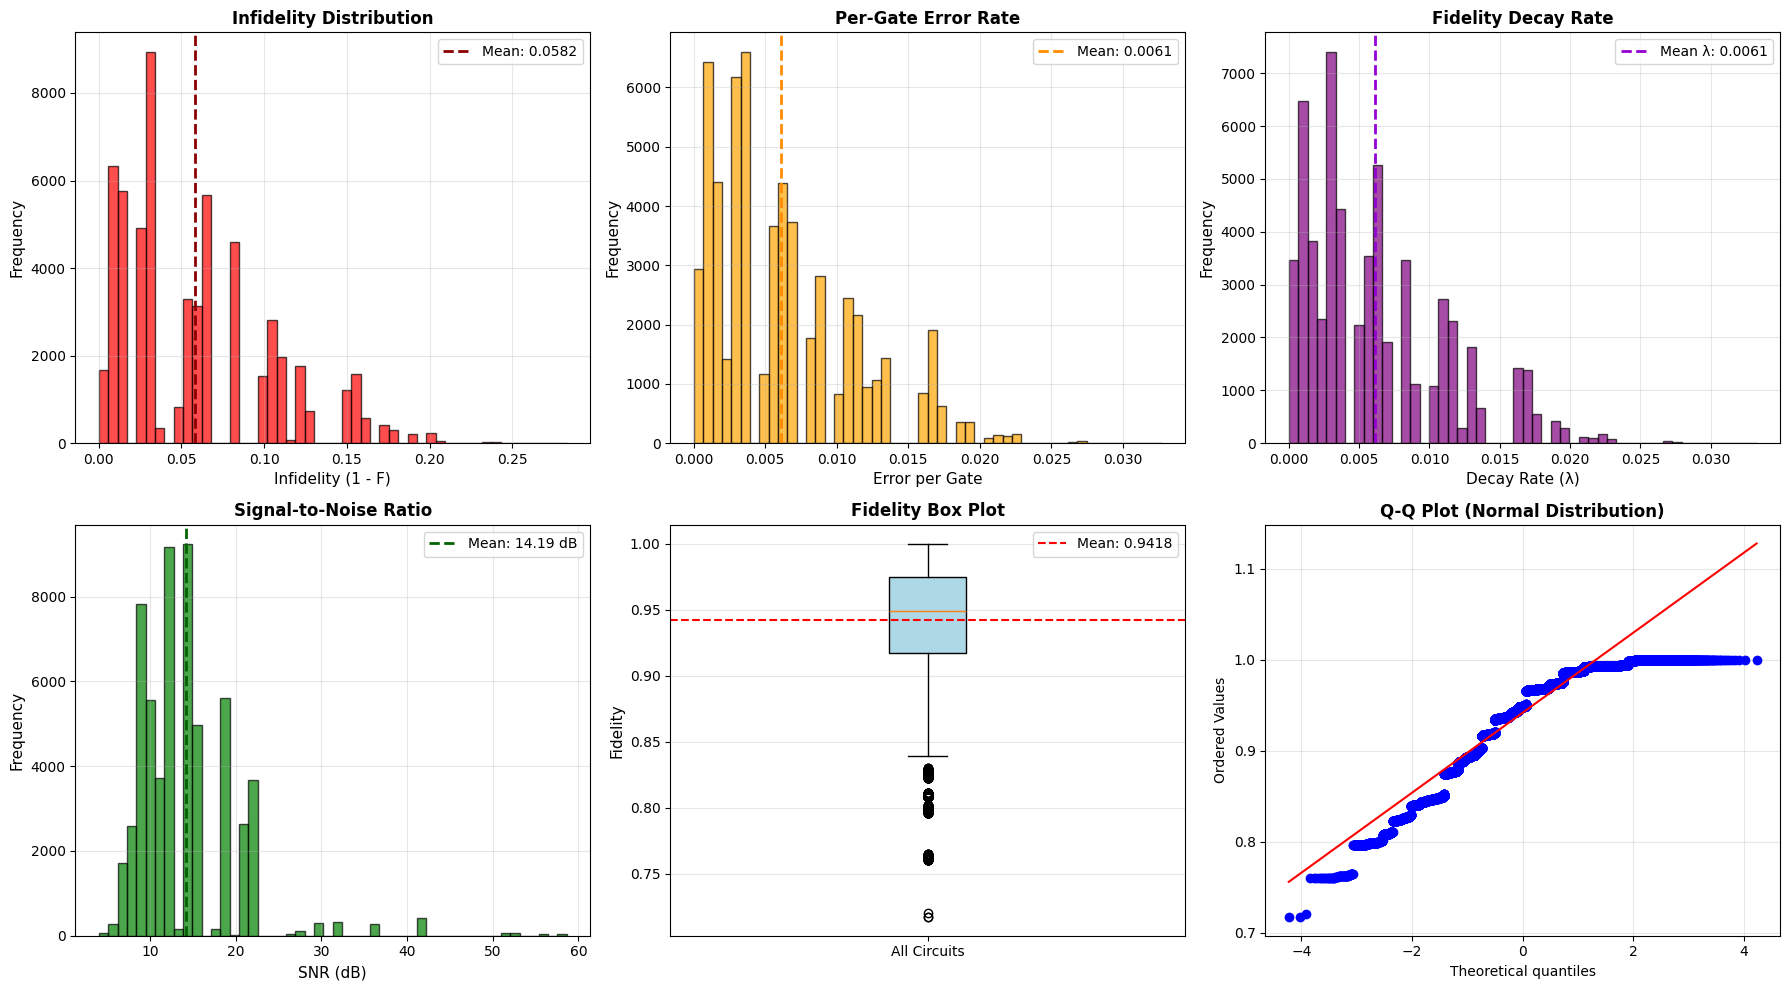


📊 Visualization complete!


In [16]:
# Advanced visualizations for noise impact
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Infidelity distribution
axes[0, 0].hist(infidelity, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(mean_infidelity, color='darkred', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_infidelity:.4f}')
axes[0, 0].set_xlabel('Infidelity (1 - F)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Infidelity Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Error per gate
axes[0, 1].hist(error_per_gate, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(np.mean(error_per_gate), color='darkorange', linestyle='--', 
                   linewidth=2, label=f'Mean: {np.mean(error_per_gate):.4f}')
axes[0, 1].set_xlabel('Error per Gate', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Per-Gate Error Rate', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Decay rate distribution
axes[0, 2].hist(decay_rate, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(np.mean(decay_rate), color='darkviolet', linestyle='--', 
                   linewidth=2, label=f'Mean λ: {np.mean(decay_rate):.4f}')
axes[0, 2].set_xlabel('Decay Rate (λ)', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title('Fidelity Decay Rate', fontsize=12, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. SNR distribution
axes[1, 0].hist(snr_db, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(np.mean(snr_db), color='darkgreen', linestyle='--', 
                   linewidth=2, label=f'Mean: {np.mean(snr_db):.2f} dB')
axes[1, 0].set_xlabel('SNR (dB)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Signal-to-Noise Ratio', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Box plot for fidelity comparison
box_data = [total_fidelity]
bp = axes[1, 1].boxplot(box_data, labels=['All Circuits'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1, 1].set_ylabel('Fidelity', fontsize=11)
axes[1, 1].set_title('Fidelity Box Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].axhline(np.mean(total_fidelity), color='red', linestyle='--', 
                   linewidth=1.5, label=f'Mean: {np.mean(total_fidelity):.4f}')
axes[1, 1].legend()

# 6. Q-Q plot for normality check
stats.probplot(total_fidelity, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q Plot (Normal Distribution)', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Visualization complete!")

In [17]:
# Gate-specific noise sensitivity analysis
# Analyze circuits by their first gate, last gate, or gate patterns

# Group circuits by dominant gate (most frequent)
circuit_stats_by_dominant = {}
for i, name in enumerate(circuit_names):
    gates = name.split('-')
    gate_counter = Counter(gates)
    dominant_gate = gate_counter.most_common(1)[0][0]
    
    if dominant_gate not in circuit_stats_by_dominant:
        circuit_stats_by_dominant[dominant_gate] = []
    circuit_stats_by_dominant[dominant_gate].append(total_fidelity[i])

# Also analyze by first and last gate
first_gate_stats = {}
last_gate_stats = {}

for i, name in enumerate(circuit_names):
    gates = name.split('-')
    first = gates[0]
    last = gates[-1]
    
    if first not in first_gate_stats:
        first_gate_stats[first] = []
    first_gate_stats[first].append(total_fidelity[i])
    
    if last not in last_gate_stats:
        last_gate_stats[last] = []
    last_gate_stats[last].append(total_fidelity[i])

print("=" * 70)
print("GATE POSITION SENSITIVITY ANALYSIS")
print("=" * 70)

print("\nCircuits grouped by FIRST GATE:")
for gate in GATES:
    if gate in first_gate_stats:
        fids = first_gate_stats[gate]
        print(f"   {gate.upper()}: Mean={np.mean(fids):.6f}, Std={np.std(fids):.6f}, n={len(fids)}")

print("\nCircuits grouped by LAST GATE:")
for gate in GATES:
    if gate in last_gate_stats:
        fids = last_gate_stats[gate]
        print(f"   {gate.upper()}: Mean={np.mean(fids):.6f}, Std={np.std(fids):.6f}, n={len(fids)}")

print("\nCircuits grouped by DOMINANT GATE (most frequent):")
for gate in GATES:
    if gate in circuit_stats_by_dominant:
        fids = circuit_stats_by_dominant[gate]
        print(f"   {gate.upper()}: Mean={np.mean(fids):.6f}, Std={np.std(fids):.6f}, n={len(fids)}")

print("=" * 70)

GATE POSITION SENSITIVITY ANALYSIS

Circuits grouped by FIRST GATE:
   X: Mean=0.941690, Std=0.046184, n=19683
   Z: Mean=0.941846, Std=0.046092, n=19683
   H: Mean=0.941833, Std=0.046037, n=19683

Circuits grouped by LAST GATE:
   X: Mean=0.944755, Std=0.043677, n=19683
   Z: Mean=0.944766, Std=0.043670, n=19683
   H: Mean=0.935848, Std=0.050090, n=19683

Circuits grouped by DOMINANT GATE (most frequent):
   X: Mean=0.949369, Std=0.040478, n=19683
   Z: Mean=0.949384, Std=0.040506, n=19683
   H: Mean=0.926616, Std=0.052462, n=19683


In [18]:
# Export comprehensive noise analysis report
report_path = f'../noise_analysis_report_{NUM_GATES}gates.txt'

with open(report_path, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write(f"COMPREHENSIVE NOISE ANALYSIS REPORT\n")
    f.write(f"Generated: {NUM_GATES}-gate circuits with {X_NOISE[0]:.2f} X/Z noise\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("BASIC STATISTICS:\n")
    f.write(f"  Total circuits: {len(all_possible_circuits)}\n")
    f.write(f"  Mean fidelity: {np.mean(total_fidelity):.6f}\n")
    f.write(f"  Median fidelity: {np.median(total_fidelity):.6f}\n")
    f.write(f"  Std deviation: {np.std(total_fidelity):.6f}\n")
    f.write(f"  Min/Max: {np.min(total_fidelity):.6f} / {np.max(total_fidelity):.6f}\n\n")
    
    f.write("NOISE IMPACT METRICS:\n")
    f.write(f"  Mean infidelity (1-F): {mean_infidelity:.6f}\n")
    f.write(f"  Mean error per gate: {np.mean(error_per_gate):.6f}\n")
    f.write(f"  Mean decay rate (λ): {np.mean(decay_rate):.6f}\n")
    f.write(f"  Mean SNR: {np.mean(snr_db):.2f} dB\n")
    f.write(f"  Coefficient of variation: {cv:.4f}\n\n")
    
    f.write("DISTRIBUTION CHARACTERISTICS:\n")
    f.write(f"  Skewness: {skewness:.4f}\n")
    f.write(f"  Kurtosis: {kurtosis_val:.4f}\n")
    f.write(f"  IQR: {iqr:.6f}\n")
    f.write(f"  Shannon Entropy: {entropy:.4f} bits\n\n")
    
    f.write("ROBUSTNESS THRESHOLDS:\n")
    f.write(f"  Fidelity > 0.90: {threshold_90:.2f}% of circuits\n")
    f.write(f"  Fidelity > 0.80: {threshold_80:.2f}% of circuits\n")
    f.write(f"  Fidelity > 0.70: {threshold_70:.2f}% of circuits\n\n")
    
    f.write("PERCENTILES:\n")
    for p, val in zip(percentiles, fidelity_percentiles):
        f.write(f"  {p:2d}th: {val:.6f}\n")
    f.write("\n")
    
    f.write("TOP 10 CIRCUITS:\n")
    for i, idx in enumerate(np.argsort(total_fidelity)[-10:][::-1]):
        f.write(f"  {i+1:2d}. {circuit_names[idx]:30s} F={total_fidelity[idx]:.6f}\n")
    f.write("\n")
    
    f.write("WORST 10 CIRCUITS:\n")
    for i, idx in enumerate(np.argsort(total_fidelity)[:10]):
        f.write(f"  {i+1:2d}. {circuit_names[idx]:30s} F={total_fidelity[idx]:.6f}\n")
    f.write("\n")
    
    f.write("=" * 80 + "\n")

print(f"✅ Comprehensive analysis report saved to: {report_path}")

✅ Comprehensive analysis report saved to: ../noise_analysis_report_10gates.txt


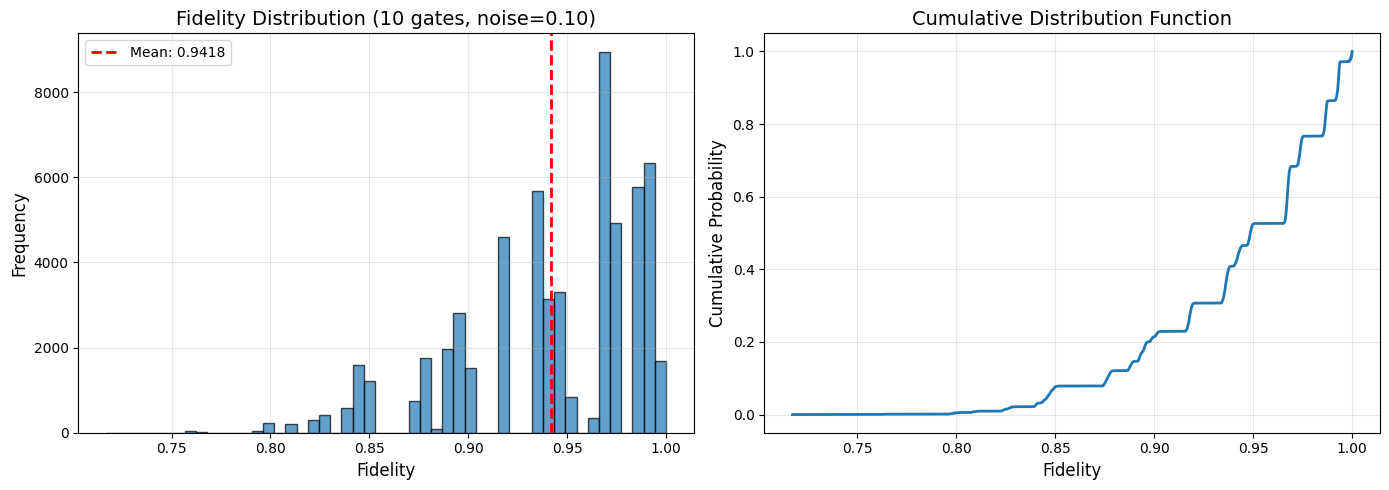


Percentage of circuits with fidelity > 0.9: 78.55%
Percentage of circuits with fidelity > 0.8: 99.52%


In [19]:
import matplotlib.pyplot as plt

# Plot fidelity distribution (total_fidelity is already numpy array)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(total_fidelity, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(total_fidelity), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(total_fidelity):.4f}')
axes[0].set_xlabel('Fidelity', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Fidelity Distribution ({NUM_GATES} gates, noise={X_NOISE[0]:.2f})', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_fidelities = np.sort(total_fidelity)
cumulative = np.arange(1, len(sorted_fidelities) + 1) / len(sorted_fidelities)
axes[1].plot(sorted_fidelities, cumulative, linewidth=2)
axes[1].set_xlabel('Fidelity', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('Cumulative Distribution Function', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPercentage of circuits with fidelity > 0.9: {100 * np.mean(total_fidelity > 0.9):.2f}%")
print(f"Percentage of circuits with fidelity > 0.8: {100 * np.mean(total_fidelity > 0.8):.2f}%")

In [20]:
out_file_path = f'../{NUM_GATES}_gate_qubit_fidelities.log'
with open(out_file_path, 'w') as f:
    for circ_str, fid in circuit_fids:
        f.write(f'Circuit: {circ_str} | Fidelity: {fid:.6f}\n') 
f.close()

print(f"Fidelity results written to {out_file_path}")


Fidelity results written to ../10_gate_qubit_fidelities.log
